# 🌫️ Air Quality Index EDA — India (2015–2023)
### Pollutant Pattern Discovery using Matplotlib & Seaborn

**Dataset:** 32,870 records · 15 features · 9 years · 4 Zones · 9 States · 3 Dominant Pollutants

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CHARTS = 'charts/'

df = pd.read_csv('10_air_quality_index_2015_2023.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

CAT_ORDER  = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
CAT_COLORS = ['#00b894','#55efc4','#fdcb6e','#e17055','#d63031','#6c5ce7']
CAT_COLOR_MAP = dict(zip(CAT_ORDER, CAT_COLORS))

ZONE_COLORS = {'North':'#0984e3','South':'#d63031','East':'#6c5ce7','West':'#00b894'}

print(f"Total records  : {len(df):,}")
print(f"Year range     : {df['year'].min()} – {df['year'].max()}")
print(f"Unique stations: {df['station'].nunique()}")
print(f"Zones          : {sorted(df['zone'].unique())}")
print()
print("Category breakdown:")
print(df['category'].value_counts())
df.head()

Total records  : 32,870
Year range     : 2015 – 2023
Unique stations: 10
Zones          : ['East', 'North', 'South', 'West']

Category breakdown:
category
Satisfactory    12912
Moderate        11547
Good             4519
Poor             2890
Very Poor         769
Severe            233
Name: count, dtype: int64


,date,year,month,station,state,zone,aqi,category,pm25_ugm3,pm10_ugm3,no2_ugm3,so2_ugm3,co_mgm3,o3_ugm3,dominant_pollutant
0,2015-01-01,2015,1,Mumbai,Maharashtra,West,175,Moderate,86.1,145.5,27.8,11.5,2.26,47.2,PM2.5
1,2015-01-02,2015,1,Mumbai,Maharashtra,West,161,Moderate,78.5,104.1,41.3,21.5,2.48,70.2,PM2.5
2,2015-01-03,2015,1,Mumbai,Maharashtra,West,119,Moderate,49.4,96.1,22.8,9.4,2.59,40.7,PM2.5
3,2015-01-04,2015,1,Mumbai,Maharashtra,West,121,Moderate,51.5,95.1,28.3,8.5,2.45,35.2,PM2.5
4,2015-01-05,2015,1,Mumbai,Maharashtra,West,115,Moderate,54.0,79.9,17.0,16.7,3.16,52.2,PM2.5


---
## 1. AQI Category Distribution (Donut Chart)
Shows the overall proportion of air quality categories across the full 9-year record. The hollow centre displays the total record count — an instant baseline before deeper analysis. Satisfactory and Moderate together account for the majority, signalling persistent mid-level pollution pressure.

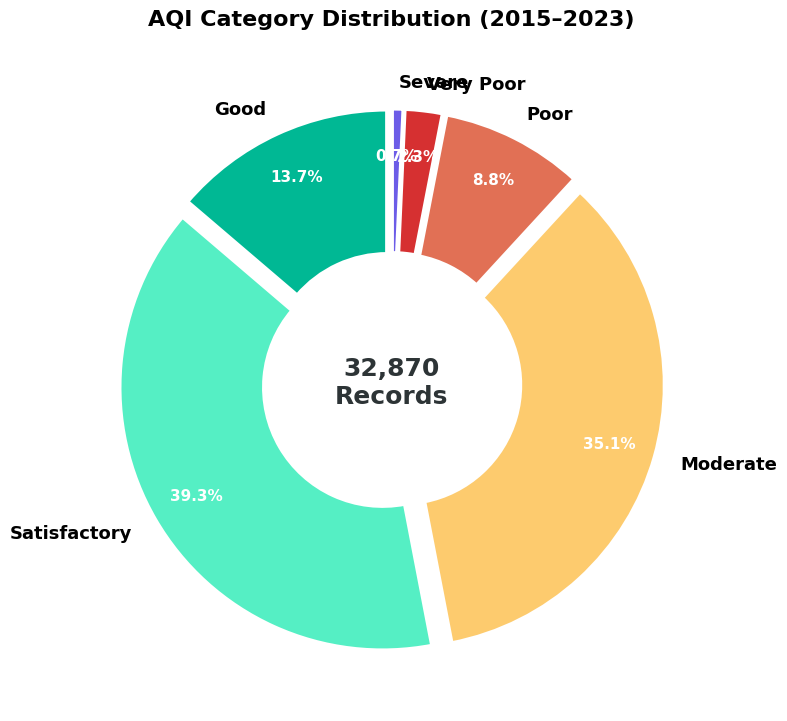

In [7]:
counts = df['category'].value_counts().reindex(CAT_ORDER).dropna()
colors_d = [CAT_COLOR_MAP[c] for c in counts.index]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors_d, startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    explode=[0.04]*len(counts))
for t in texts:      t.set_fontsize(13); t.set_fontweight('bold')
for a in autotexts:  a.set_fontsize(11); a.set_color('white'); a.set_fontweight('bold')
ax.text(0, 0, f'{len(df):,}\nRecords', ha='center', va='center',
        fontsize=18, fontweight='bold', color='#2d3436')
ax.set_title('AQI Category Distribution (2015–2023)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(CHARTS+'01_category_donut.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Annual AQI Trend — Line + Area Chart by Zone
Tracks mean AQI year-on-year for each geographic zone. Shaded fills encode cumulative air-quality pressure over time. The sharp dip in 2020 across all zones is a clear COVID-19 lockdown signal; any post-2021 rebound reveals the pace of pollution recovery.

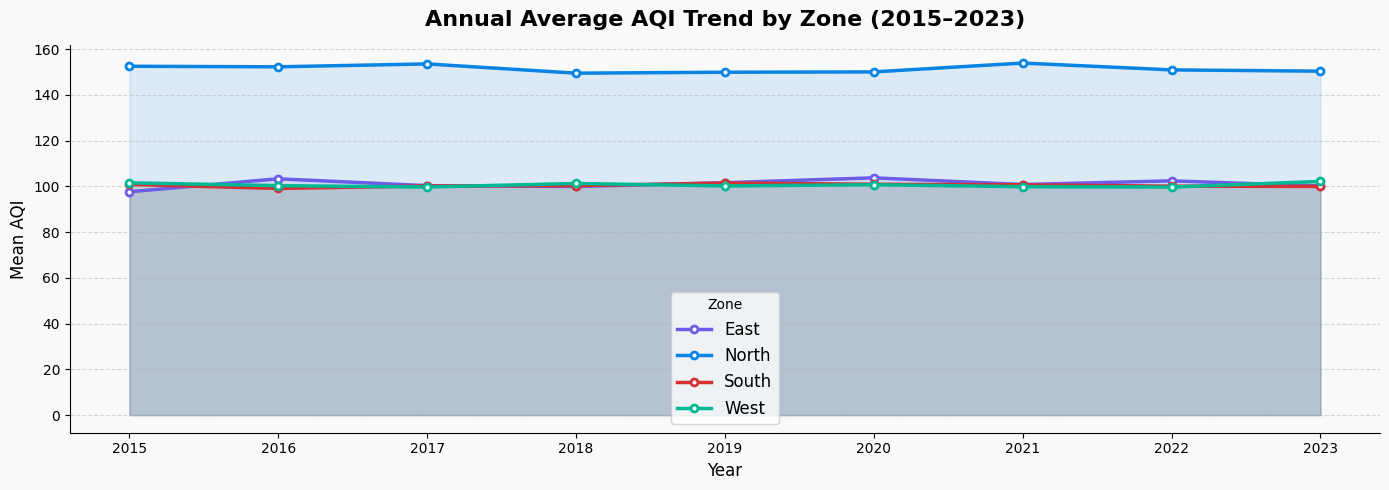

In [8]:
yearly_zone = df.groupby(['year','zone'])['aqi'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
for zone in yearly_zone.columns:
    c = ZONE_COLORS.get(zone, '#636e72')
    ax.fill_between(yearly_zone.index, yearly_zone[zone], alpha=0.12, color=c)
    ax.plot(yearly_zone.index, yearly_zone[zone], color=c, lw=2.5,
            marker='o', ms=5, markerfacecolor='white', markeredgewidth=2, label=zone)
ax.set_title('Annual Average AQI Trend by Zone (2015–2023)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=12); ax.set_ylabel('Mean AQI', fontsize=12)
ax.legend(fontsize=12, title='Zone'); ax.set_facecolor('#f9f9f9'); fig.patch.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS+'02_annual_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Monthly Seasonality — Polar Bar Chart by Zone
Wraps 12 months onto a wheel with side-by-side bars for each zone. The winter (Oct–Feb) spike reveals India's biomass burning and temperature-inversion season, while the monsoon months (Jun–Sep) often show a temporary AQI improvement due to wet scavenging of particulates.

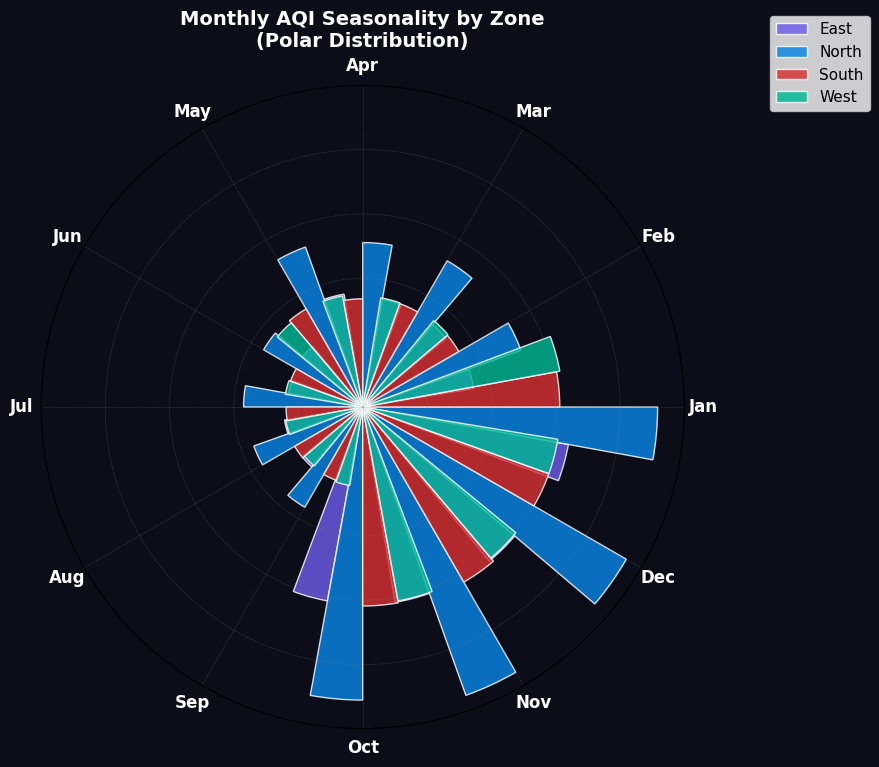

In [9]:
monthly_zone = df.groupby(['month','zone'])['aqi'].mean().unstack()
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
width  = 0.18

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, zone in enumerate(monthly_zone.columns):
    vals = monthly_zone[zone].reindex(range(1,13), fill_value=0).values
    c = ZONE_COLORS.get(zone,'#636e72')
    ax.bar(angles + (i-1.5)*width, vals, width=width, color=c,
           alpha=0.82, label=zone, edgecolor='white', linewidth=1)
ax.set_xticks(angles); ax.set_xticklabels(months_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Monthly AQI Seasonality by Zone\n(Polar Distribution)', fontsize=14, fontweight='bold', pad=28)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.12), fontsize=11)
ax.grid(color='grey', linestyle='--', linewidth=0.4, alpha=0.4)
fig.patch.set_facecolor('#0d0d1a'); ax.set_facecolor('#0d0d1a'); ax.title.set_color('white')
for label in ax.get_xticklabels(): label.set_color('white')
plt.tight_layout()
plt.savefig(CHARTS+'03_monthly_polar.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## 4. AQI by Category & Zone — Side-by-Side Violin + Strip
Violin width = record density at each AQI level. White strip dots = individual readings. The left panel confirms category thresholds are internally consistent; the right panel reveals how North and East zones consistently skew toward higher AQI compared to South, reflecting India's Indo-Gangetic plain pollution dynamics.

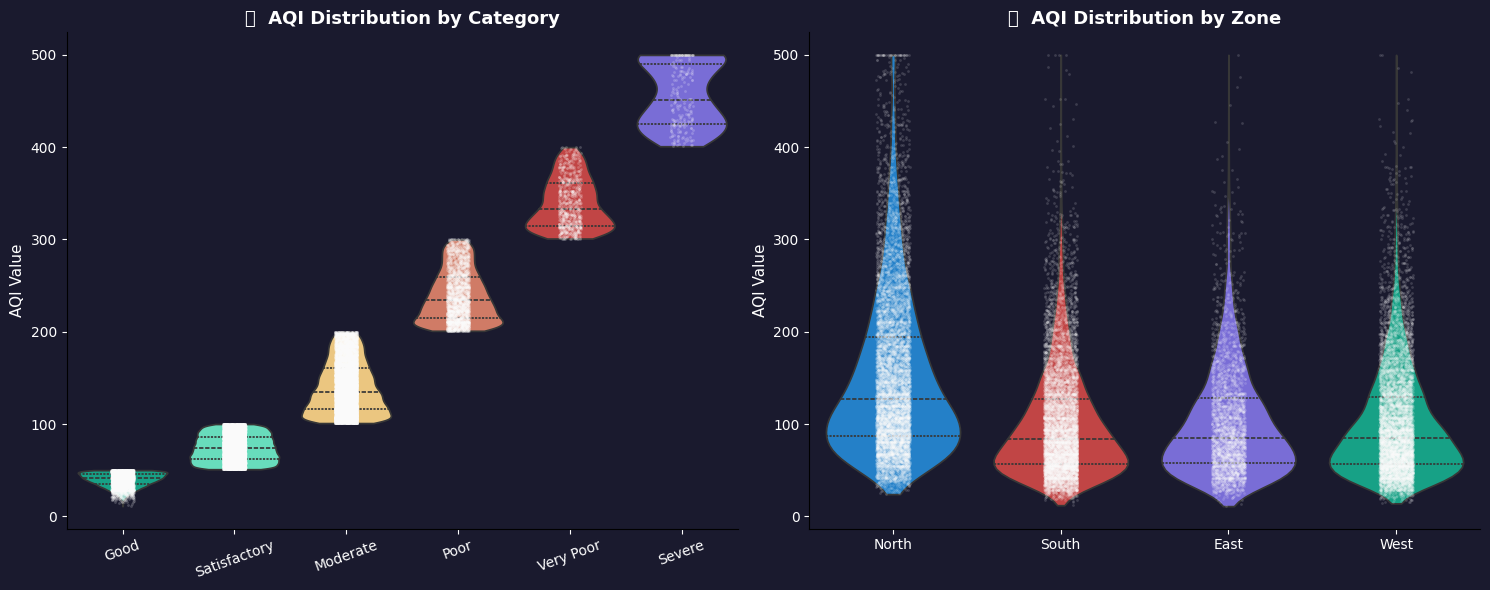

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
CAT_PAL = ['#00b894','#55efc4','#fdcb6e','#e17055','#d63031','#6c5ce7']
df_cat = df[df['category'].isin(CAT_ORDER)]

sns.violinplot(data=df_cat, y='aqi', x='category', order=CAT_ORDER,
               palette=CAT_PAL, ax=axes[0], inner='quartile', cut=0)
sns.stripplot(data=df_cat, y='aqi', x='category', order=CAT_ORDER,
              color='white', alpha=0.2, size=2, jitter=True, ax=axes[0])
axes[0].set_title('💨  AQI Distribution by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('AQI Value', fontsize=11)
axes[0].set_facecolor('#1a1a2e'); axes[0].title.set_color('white')
axes[0].yaxis.label.set_color('white'); axes[0].tick_params(colors='white')
axes[0].tick_params(axis='x', rotation=20)

sns.violinplot(data=df, y='aqi', x='zone', order=['North','South','East','West'],
               palette=[ZONE_COLORS[z] for z in ['North','South','East','West']],
               ax=axes[1], inner='quartile', cut=0)
sns.stripplot(data=df, y='aqi', x='zone', order=['North','South','East','West'],
              color='white', alpha=0.15, size=2, jitter=True, ax=axes[1])
axes[1].set_title('🗺️  AQI Distribution by Zone', fontsize=13, fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('AQI Value', fontsize=11)
axes[1].set_facecolor('#1a1a2e'); axes[1].title.set_color('white')
axes[1].yaxis.label.set_color('white'); axes[1].tick_params(colors='white')

fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(CHARTS+'04_aqi_violin.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 5. PM2.5 vs AQI — Bubble Scatter (Bubble Size = PM10)
Each point sits at the intersection of PM2.5 concentration and AQI. Bubble size encodes PM10 load; colour encodes zone. Stations annotated in red are the top-4 all-time worst readings. The strong linear cluster confirms PM2.5 is the dominant driver of AQI for most observations.

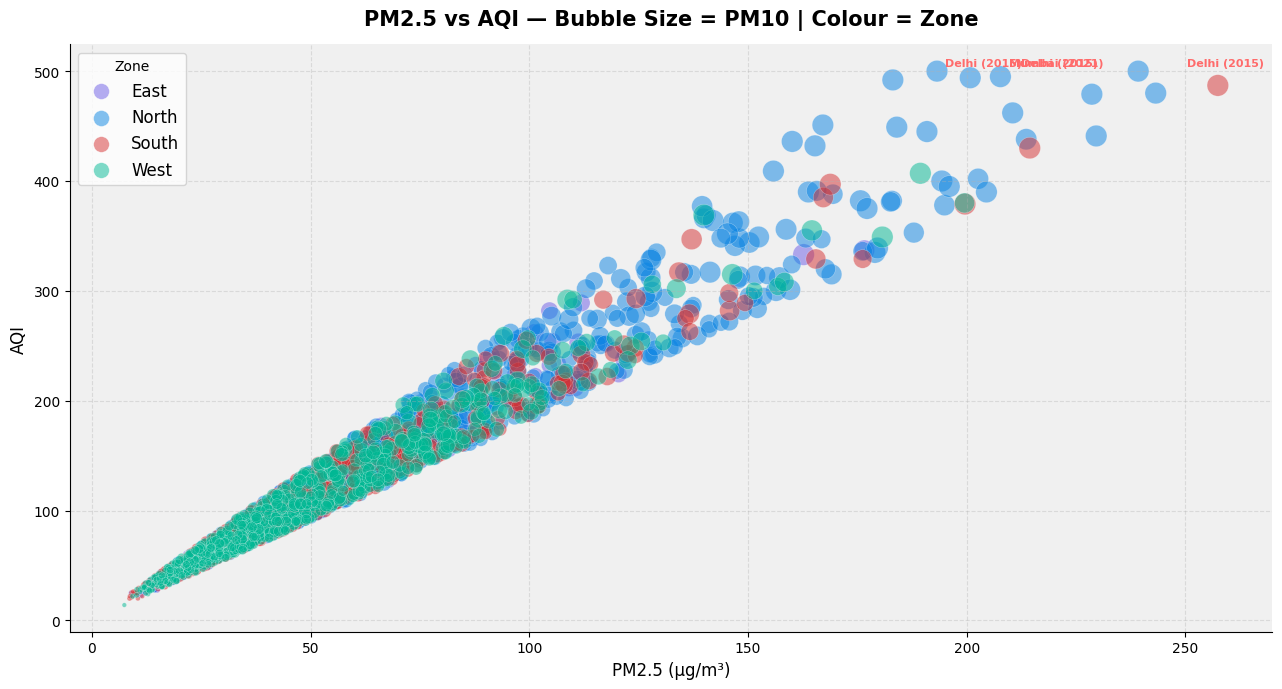

In [11]:
sample = df.dropna(subset=['pm25_ugm3','pm10_ugm3']).sample(n=min(3000,len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 7))
for zone, grp in sample.groupby('zone'):
    c = ZONE_COLORS.get(zone,'#636e72')
    ax.scatter(grp['pm25_ugm3'], grp['aqi'], c=c, alpha=0.5,
               s=grp['pm10_ugm3'].clip(10,300)*0.8,
               edgecolors='white', linewidths=0.3, label=zone)

top4 = df.dropna(subset=['pm25_ugm3']).nlargest(4,'aqi')
for _, r in top4.iterrows():
    ax.annotate(f"{r['station']} ({r['year']})", (r['pm25_ugm3'], r['aqi']),
                xytext=(8,4), textcoords='offset points', fontsize=8,
                color='#ff6b6b', fontweight='bold')

ax.set_title('PM2.5 vs AQI — Bubble Size = PM10 | Colour = Zone', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12); ax.set_ylabel('AQI', fontsize=12)
ax.legend(fontsize=12, title='Zone'); ax.set_facecolor('#f0f0f0'); ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig(CHARTS+'05_pm25_aqi_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Year × Month Mean AQI Heatmap
Every cell = mean AQI for that year-month combination. The bright winter band (Nov–Jan) running across all years is unmistakable. The noticeably cooler row for 2020 validates the lockdown effect. Cells in Aug–Sep are consistently lighter, confirming monsoon-driven improvement.

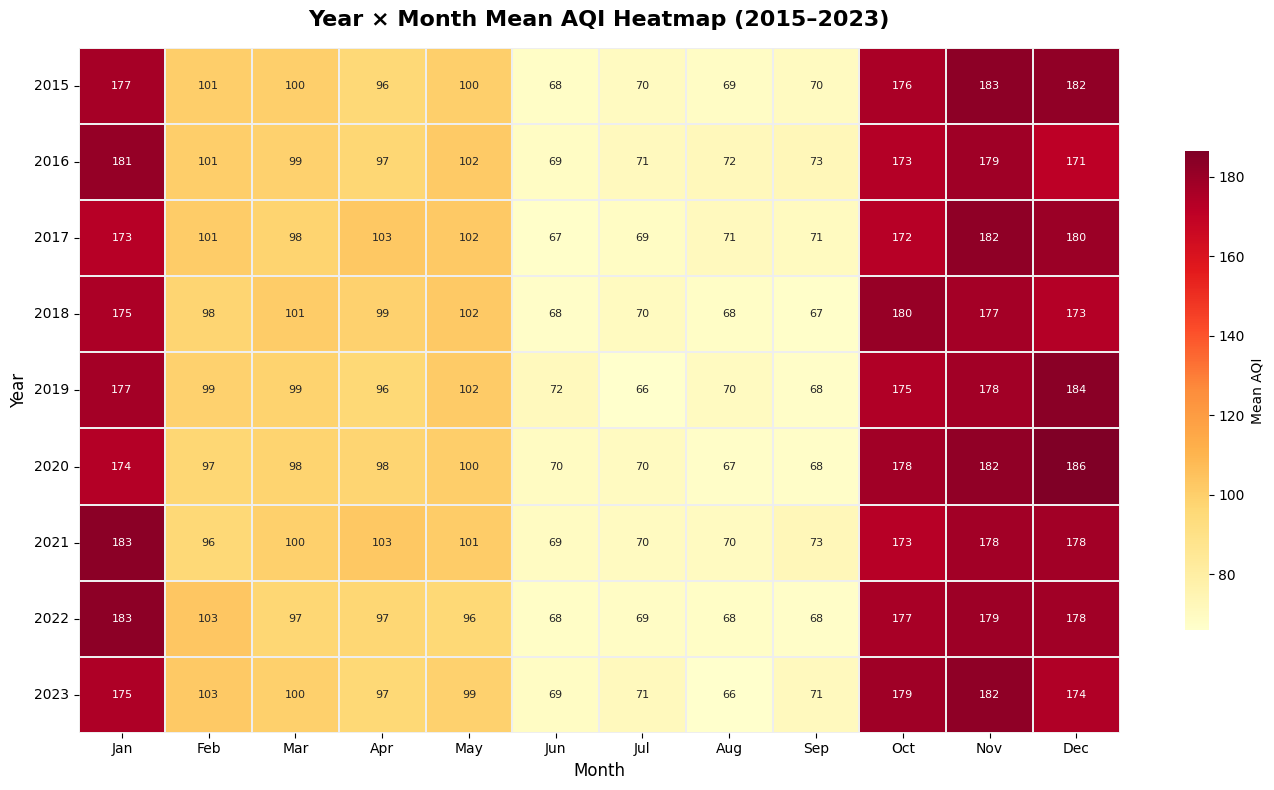

In [12]:
pivot = df.groupby(['year','month'])['aqi'].mean().unstack()
all_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [all_months[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='#eee', ax=ax,
            annot=True, fmt='.0f', cbar_kws={'label':'Mean AQI','shrink':0.7},
            annot_kws={'fontsize': 8})
ax.set_title('Year × Month Mean AQI Heatmap (2015–2023)', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12); ax.set_ylabel('Year', fontsize=12)
ax.tick_params(axis='x', rotation=0); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(CHARTS+'06_year_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Top 15 Most Polluted Stations — Horizontal Bar Chart
Colour-coded by zone. Annotated with mean AQI and zone label. Reveals which specific monitoring stations have borne the highest chronic pollution burden over the 9-year period — directly informing targeted intervention priorities.

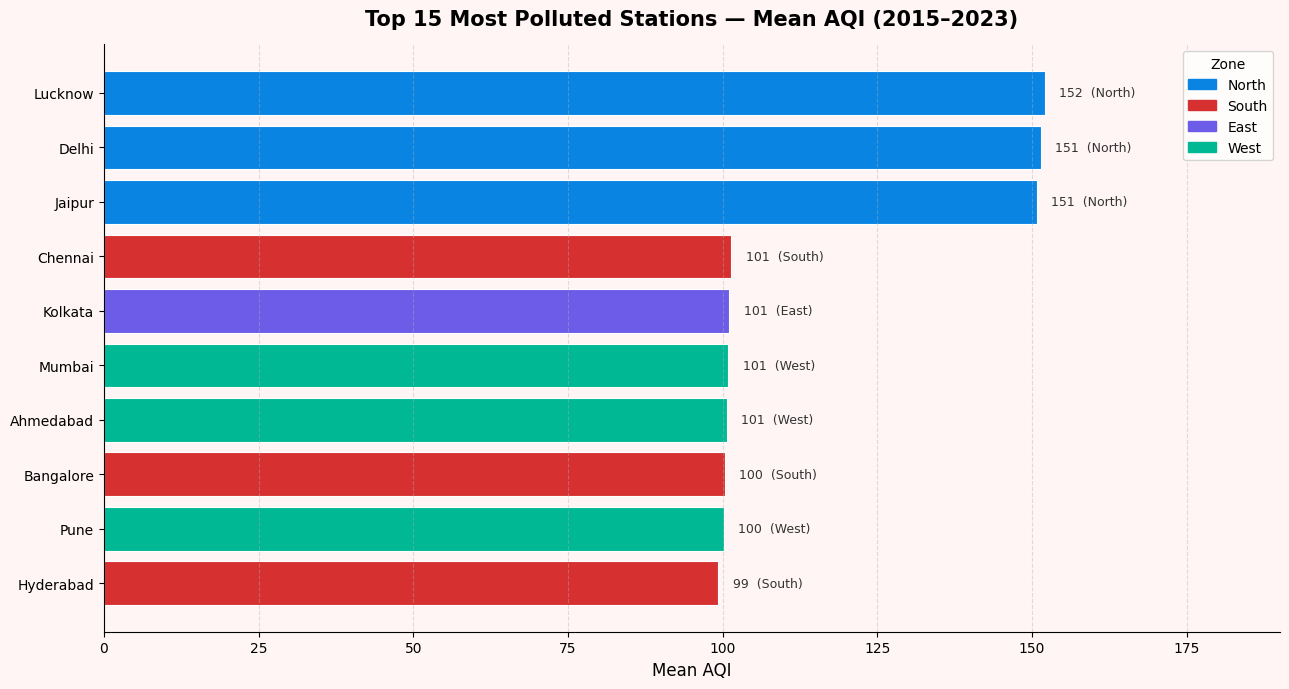

In [13]:
top15_stations = df.groupby('station')['aqi'].mean().nlargest(15).sort_values()
state_map = df.groupby('station')['state'].first()
zone_map  = df.groupby('station')['zone'].first()

bar_colors = [ZONE_COLORS.get(zone_map[s],'#636e72') for s in top15_stations.index]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top15_stations.index, top15_stations.values, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, (station, val) in zip(bars, top15_stations.items()):
    zone = zone_map[station]
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f"  {val:.0f}  ({zone})", va='center', fontsize=9, color='#333')

patches = [plt.Rectangle((0,0),1,1, color=c, label=z) for z,c in ZONE_COLORS.items()]
ax.legend(handles=patches, fontsize=10, title='Zone')
ax.set_title('Top 15 Most Polluted Stations — Mean AQI (2015–2023)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Mean AQI', fontsize=12)
ax.set_xlim(0, top15_stations.max()*1.25)
ax.set_facecolor('#fff5f5'); fig.patch.set_facecolor('#fff5f5')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS+'07_top15_stations.png', dpi=150, bbox_inches='tight', facecolor='#fff5f5')
plt.show()

---
## 8. State-wise AQI Category Breakdown — Stacked Horizontal Bar
Stacks all category counts per state. A state dominated by green (Good/Satisfactory) faces low chronic risk; dominance of red/purple (Poor/Very Poor/Severe) flags a public health priority. Directly informs state-level pollution control prioritisation.

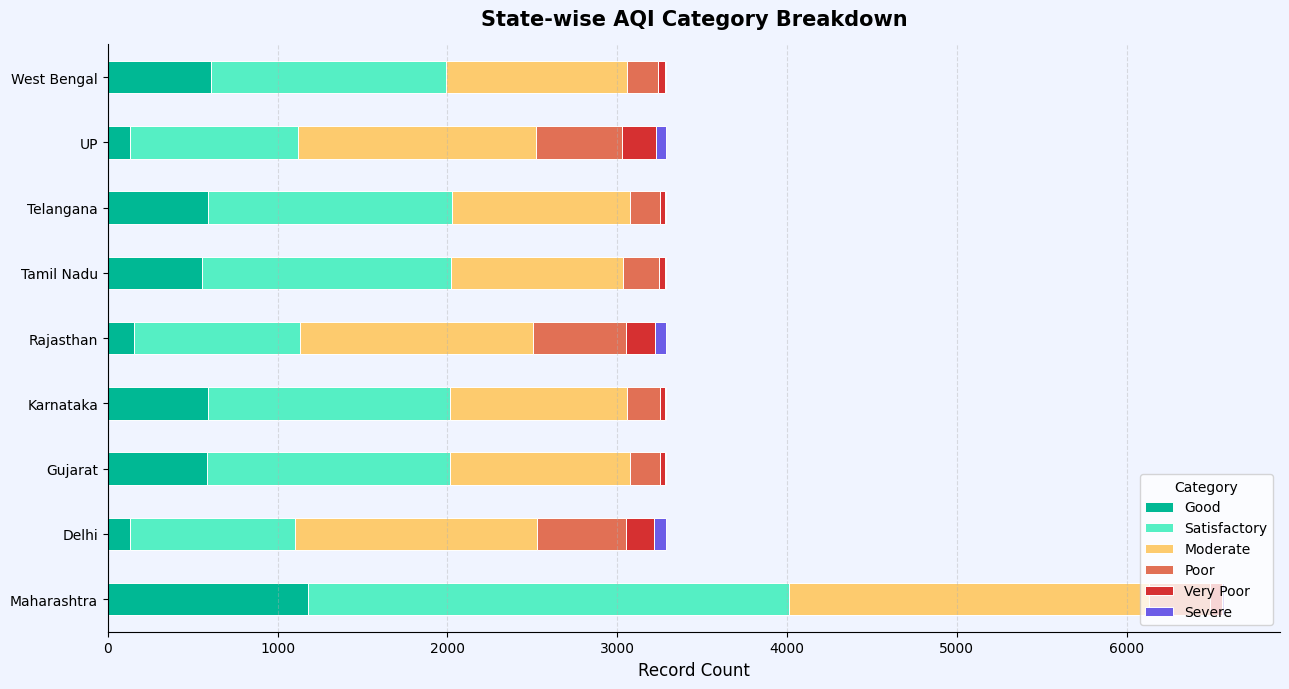

In [14]:
state_cat = df.groupby(['state','category']).size().unstack(fill_value=0)
state_cat['total'] = state_cat.sum(axis=1)
top_states = state_cat.nlargest(9,'total').drop('total',axis=1)
top_states = top_states[[c for c in CAT_ORDER if c in top_states.columns]]

CAT_PAL    = ['#00b894','#55efc4','#fdcb6e','#e17055','#d63031','#6c5ce7']
colors_used = [CAT_PAL[CAT_ORDER.index(c)] for c in top_states.columns]

fig, ax = plt.subplots(figsize=(13, 7))
top_states.plot(kind='barh', stacked=True, color=colors_used, ax=ax, edgecolor='white', linewidth=0.7)
ax.set_title('State-wise AQI Category Breakdown', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Record Count', fontsize=12); ax.set_ylabel('')
ax.legend(top_states.columns, fontsize=10, title='Category', loc='lower right')
ax.set_facecolor('#f0f4ff'); fig.patch.set_facecolor('#f0f4ff')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS+'08_state_category_stacked.png', dpi=150, bbox_inches='tight', facecolor='#f0f4ff')
plt.show()

---
## 9. AQI Category vs Dominant Pollutant — Cross-tabulation Heatmap
Maps how dominant pollutant type aligns with observed AQI category. Cells where PM2.5 dominates in the Severe row confirm fine particulate matter as the primary culprit at the worst end of the scale. NO2 dominance in lower categories reveals traffic-origin baseline pollution.

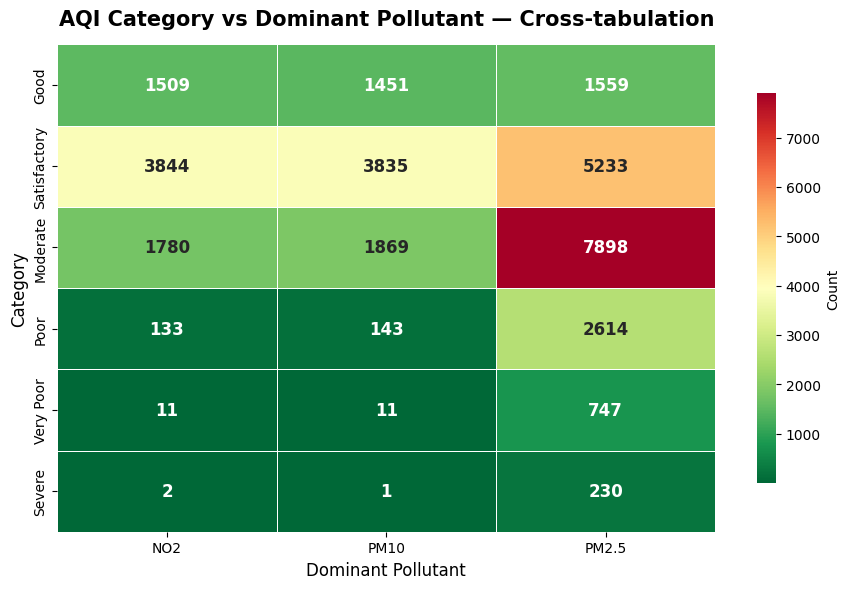

In [15]:
cat_poll = df.groupby(['category','dominant_pollutant']).size().unstack(fill_value=0)
cat_poll = cat_poll.reindex([c for c in CAT_ORDER if c in cat_poll.index])

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(cat_poll, cmap='RdYlGn_r', annot=True, fmt='d', linewidths=0.5,
            cbar_kws={'label':'Count','shrink':0.8},
            annot_kws={'fontsize':12,'fontweight':'bold'}, ax=ax)
ax.set_title('AQI Category vs Dominant Pollutant — Cross-tabulation', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Dominant Pollutant', fontsize=12); ax.set_ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(CHARTS+'09_category_pollutant_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. AQI Distribution by Year & Zone — Grouped Boxplot
Grouped boxes compare zone-level AQI spread for each year. The 2020 box shift downward across all zones marks the lockdown period. Widening IQR in recent years may indicate increasing AQI variability — more extreme both good and bad days.

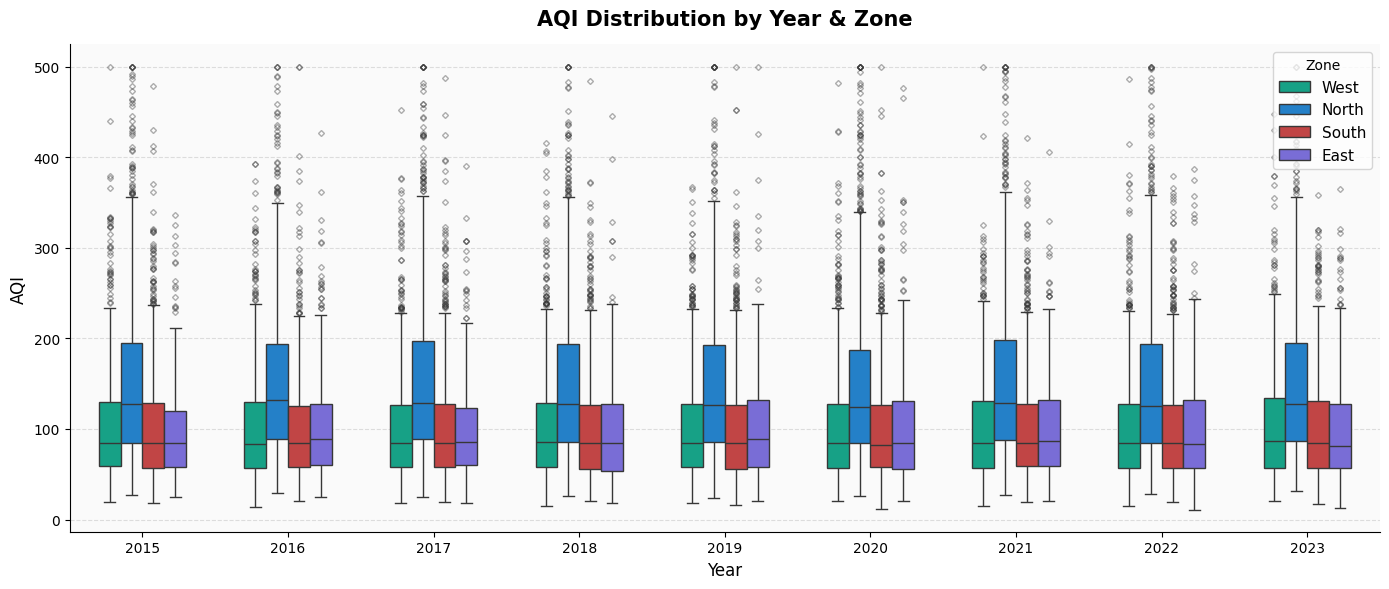

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='year', y='aqi', hue='zone',
            palette=ZONE_COLORS,
            flierprops=dict(marker='D', markersize=3, alpha=0.4),
            ax=ax, width=0.6)
ax.set_title('AQI Distribution by Year & Zone', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=12); ax.set_ylabel('AQI', fontsize=12)
ax.legend(title='Zone', fontsize=11)
ax.set_facecolor('#fafafa'); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS+'10_aqi_year_zone_box.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Pollutant Concentration Distribution — KDE + Histogram
Overlapping histograms and smooth KDE curves for PM2.5, PM10, and NO2. Mean and median lines are annotated. A longer right tail for PM2.5 indicates chronic high-load events that push AQI into the Poor/Severe range and dominate public health impact.

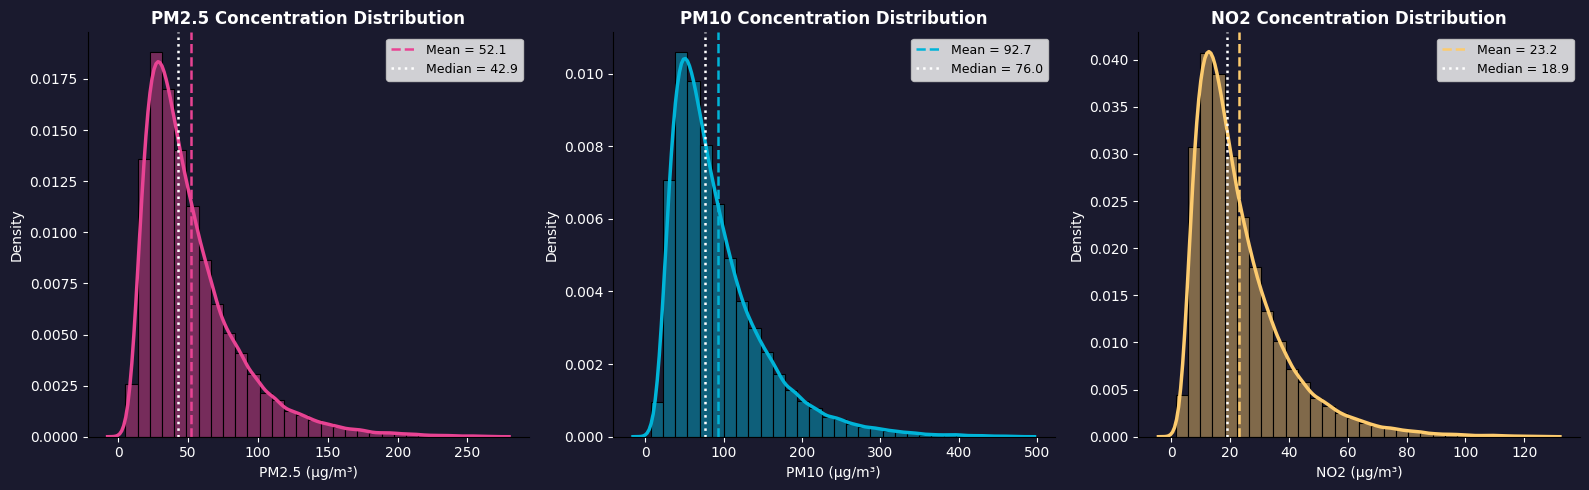

In [17]:
pollutants = [
    ('pm25_ugm3','PM2.5','#e84393'),
    ('pm10_ugm3','PM10','#00b4d8'),
    ('no2_ugm3','NO2','#fdcb6e')
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label, color) in zip(axes, pollutants):
    data = df[col].dropna()
    sns.histplot(data, bins=30, color=color, alpha=0.45, stat='density', ax=ax)
    sns.kdeplot(data, color=color, lw=2.5, ax=ax)
    ax.axvline(data.mean(),   color=color,   lw=1.8, linestyle='--', label=f"Mean = {data.mean():.1f}")
    ax.axvline(data.median(), color='white',  lw=1.8, linestyle=':',  label=f"Median = {data.median():.1f}")
    ax.set_title(f'{label} Concentration Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{label} (µg/m³)', fontsize=10); ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_facecolor('#1a1a2e'); ax.title.set_color('white')
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
    ax.tick_params(colors='white')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(CHARTS+'11_pollutant_kde.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 12. Pollutant Correlation Matrix — Lower Triangle Heatmap
Pearson correlations between AQI and all six pollutants (lower triangle only). Strong PM2.5–AQI and PM10–AQI correlations confirm particulate dominance. Weak or negative O3 correlation may reflect its photochemical origin — rising with sunlight when other pollutants drop.

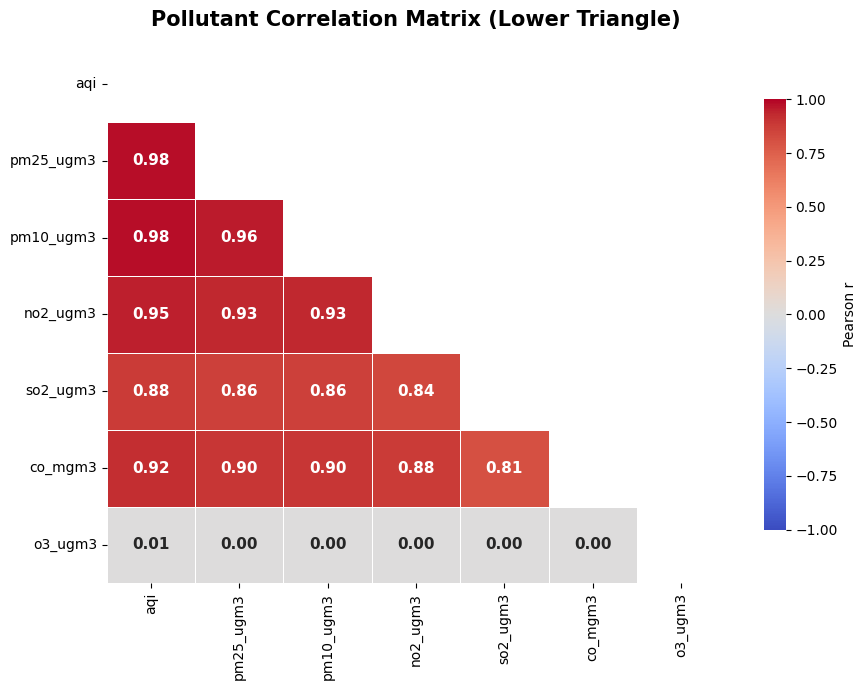

In [18]:
poll_cols = ['aqi','pm25_ugm3','pm10_ugm3','no2_ugm3','so2_ugm3','co_mgm3','o3_ugm3']
corr = df[poll_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label':'Pearson r','shrink':0.8},
            annot_kws={'fontsize':11,'fontweight':'bold'}, ax=ax)
ax.set_title('Pollutant Correlation Matrix (Lower Triangle)', fontsize=15, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(CHARTS+'12_pollutant_correlation.png', dpi=150, bbox_inches='tight')
plt.show()